# Etapa 1 — Preprocesamiento y Detección de Data Leakage
**Dataset:** Heart Failure Prediction (918 pacientes, 12 columnas)  
**Objetivo:** Clasificación binaria — predecir si un paciente tiene enfermedad cardíaca (`HeartDisease = 1`) o no (`HeartDisease = 0`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')
print('Librerías cargadas ✓')

Librerías cargadas ✓


## 1. Carga y Exploración del Dataset

In [2]:
df = pd.read_csv('../heart.csv')
print(f'Dimensiones: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')
df.head()

Dimensiones: (918, 12)
Columnas: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
print('=== INFORMACIÓN GENERAL ===')
print(df.info())
print('\n=== ESTADÍSTICAS DESCRIPTIVAS ===')
df.describe()

=== INFORMACIÓN GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None

=== ESTADÍSTICAS DESCRIPTIVAS ===


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [4]:
print('=== VALORES NULOS ===')
print(df.isnull().sum())
print('\n=== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ===')
print(df['HeartDisease'].value_counts())
print(f'Porcentaje con enfermedad: {df["HeartDisease"].mean()*100:.1f}%')

=== VALORES NULOS ===
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

=== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ===
HeartDisease
1    508
0    410
Name: count, dtype: int64
Porcentaje con enfermedad: 55.3%


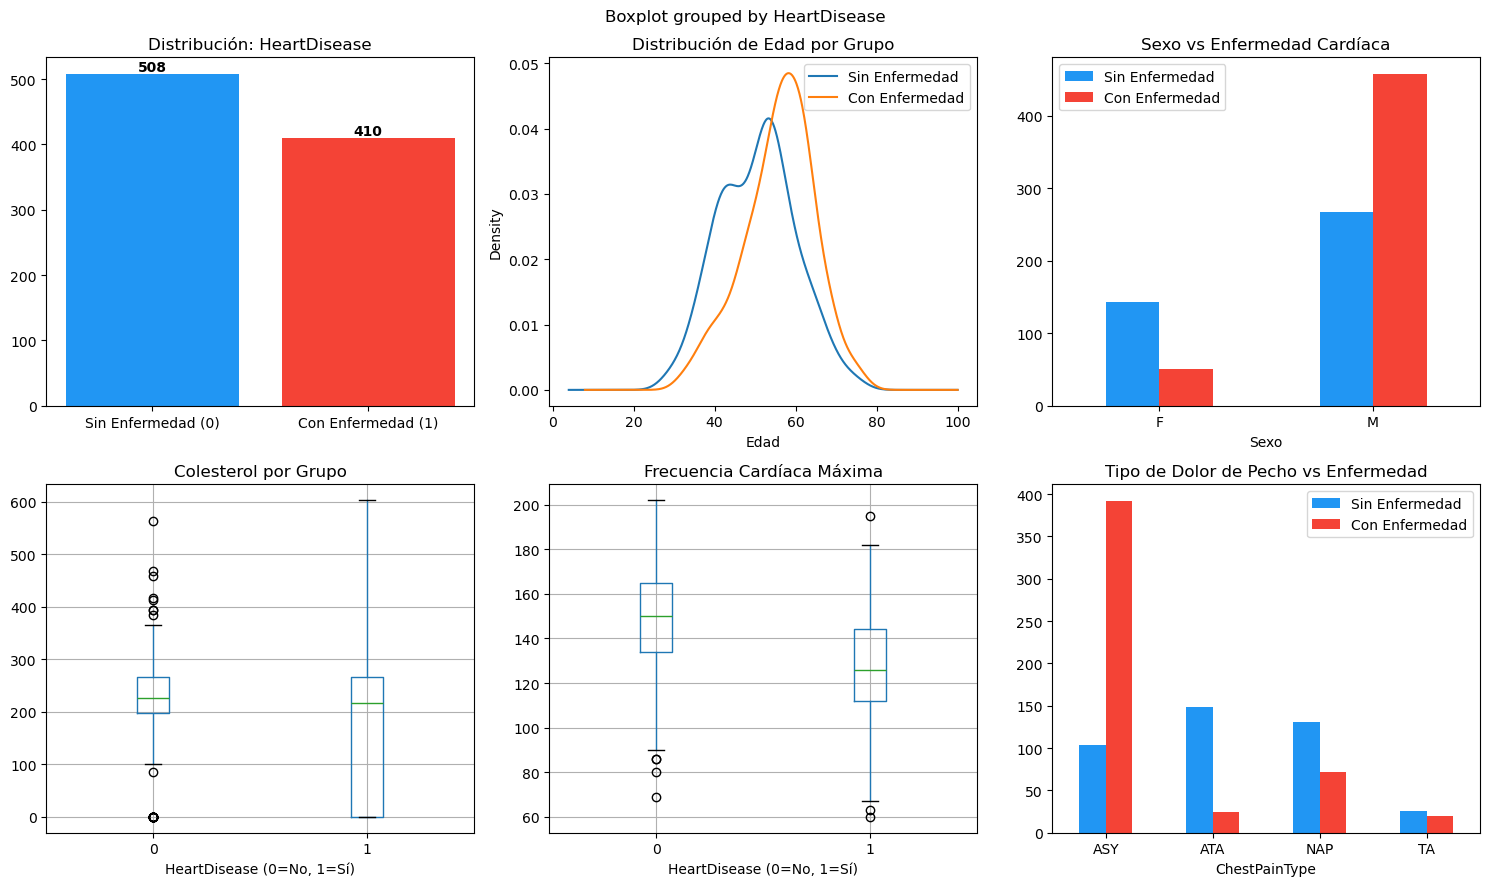

Gráfico guardado: exploratory_analysis.png ✓


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Análisis Exploratorio — Heart Disease Dataset', fontsize=14, fontweight='bold')

# 1. Distribución variable objetivo
counts = df['HeartDisease'].value_counts()
axes[0,0].bar(['Sin Enfermedad (0)', 'Con Enfermedad (1)'], counts.values, color=['#2196F3','#F44336'])
axes[0,0].set_title('Distribución: HeartDisease')
for i, v in enumerate(counts.values):
    axes[0,0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 2. Edad por grupo
df.groupby('HeartDisease')['Age'].plot(kind='kde', ax=axes[0,1], legend=True)
axes[0,1].set_title('Distribución de Edad por Grupo')
axes[0,1].set_xlabel('Edad')
axes[0,1].legend(['Sin Enfermedad', 'Con Enfermedad'])

# 3. Sexo vs HeartDisease
pd.crosstab(df['Sex'], df['HeartDisease']).plot(kind='bar', ax=axes[0,2], color=['#2196F3','#F44336'])
axes[0,2].set_title('Sexo vs Enfermedad Cardíaca')
axes[0,2].set_xlabel('Sexo')
axes[0,2].legend(['Sin Enfermedad', 'Con Enfermedad'])
axes[0,2].tick_params(rotation=0)

# 4. Colesterol
df.boxplot(column='Cholesterol', by='HeartDisease', ax=axes[1,0])
axes[1,0].set_title('Colesterol por Grupo')
axes[1,0].set_xlabel('HeartDisease (0=No, 1=Sí)')

# 5. MaxHR
df.boxplot(column='MaxHR', by='HeartDisease', ax=axes[1,1])
axes[1,1].set_title('Frecuencia Cardíaca Máxima')
axes[1,1].set_xlabel('HeartDisease (0=No, 1=Sí)')

# 6. Tipo de dolor de pecho
pd.crosstab(df['ChestPainType'], df['HeartDisease']).plot(kind='bar', ax=axes[1,2], color=['#2196F3','#F44336'])
axes[1,2].set_title('Tipo de Dolor de Pecho vs Enfermedad')
axes[1,2].tick_params(rotation=0)
axes[1,2].legend(['Sin Enfermedad', 'Con Enfermedad'])

plt.tight_layout()
plt.savefig('../exploratory_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: exploratory_analysis.png ✓')

## 2. Preprocesamiento — Encoding de Variables Categóricas

In [6]:
# Las columnas categóricas de este dataset son:
# Sex, ChestPainType, RestingECG, ExerciseAngina, ST_Slope
print('Columnas categóricas:')
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)
for col in cat_cols:
    print(f'  {col}: {df[col].unique()}')

Columnas categóricas:
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
  Sex: ['M' 'F']
  ChestPainType: ['ATA' 'NAP' 'ASY' 'TA']
  RestingECG: ['Normal' 'ST' 'LVH']
  ExerciseAngina: ['N' 'Y']
  ST_Slope: ['Up' 'Flat' 'Down']


In [7]:
# One-Hot Encoding (drop_first para evitar multicolinealidad)
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

print(f'Shape después del encoding: X={X.shape}, y={y.shape}')
print(f'Features finales ({len(X.columns)}):')
print(X.columns.tolist())

Shape después del encoding: X=(918, 15), y=(918,)
Features finales (15):
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


## 3. Demostración de Data Leakage — Flujo INCORRECTO ❌

In [8]:
print('=' * 55)
print('  FLUJO INCORRECTO — Con Data Leakage (NO hacer esto)')
print('=' * 55)
print()
print('Error: se escala TODO el dataset ANTES de dividirlo.')
print('Esto filtra estadísticas del test set al entrenamiento.')
print('El modelo "ve" información que no debería conocer.')
print()

# Feature artificial que introduce fuga directa
X_leaky = X.copy()
np.random.seed(0)
X_leaky['leaky_feature'] = y + np.random.normal(0, 0.01, size=len(y))

# ERROR: fit_transform sobre todo antes de dividir
scaler_bad = MinMaxScaler()
X_scaled_bad = scaler_bad.fit_transform(X_leaky)
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_scaled_bad, y, test_size=0.2, random_state=42
)

grid_leaky = GridSearchCV(
    SVC(probability=True),
    param_grid={'C': [0.1, 1, 10], 'gamma': [0.01, 0.1]},
    cv=5, scoring='roc_auc'
)
grid_leaky.fit(X_train_l, y_train_l)
auc_leaky = roc_auc_score(y_test_l, grid_leaky.predict_proba(X_test_l)[:, 1])

print(f'AUC con fuga: {auc_leaky:.4f}  ← inflado artificialmente, NO es real')

  FLUJO INCORRECTO — Con Data Leakage (NO hacer esto)

Error: se escala TODO el dataset ANTES de dividirlo.
Esto filtra estadísticas del test set al entrenamiento.
El modelo "ve" información que no debería conocer.

AUC con fuga: 1.0000  ← inflado artificialmente, NO es real


## 4. Flujo Correcto — Sin Data Leakage ✅

In [9]:
print('=' * 55)
print('  FLUJO CORRECTO — Sin Data Leakage')
print('=' * 55)
print()
print('Corrección: dividir PRIMERO, luego el scaler vive')
print('DENTRO del Pipeline y solo aprende del train set.')
print()

# División ANTES de cualquier transformación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Balance train — 0: {(y_train==0).sum()} | 1: {(y_train==1).sum()}')

  FLUJO CORRECTO — Sin Data Leakage

Corrección: dividir PRIMERO, luego el scaler vive
DENTRO del Pipeline y solo aprende del train set.

Train: (734, 15) | Test: (184, 15)
Balance train — 0: 328 | 1: 406


## 5. Funciones Reutilizables de Entrenamiento y Evaluación

In [10]:
def train_pipeline(X_train, y_train, model, param_grid, model_name='Model'):
    """
    Entrena un Pipeline (MinMaxScaler + clasificador) con GridSearchCV.
    El scaler se ajusta SOLO sobre el train set en cada fold.
    """
    # Prefijar parámetros con 'clf__' para el Pipeline
    prefixed_params = {f'clf__{k}': v for k, v in param_grid.items()}

    pipe = Pipeline([
        ('scaler', MinMaxScaler()),
        ('clf', model)
    ])

    grid = GridSearchCV(
        pipe, prefixed_params,
        cv=5, scoring='roc_auc', n_jobs=-1
    )
    grid.fit(X_train, y_train)

    print(f'  ✓ {model_name:<22} | AUC CV: {grid.best_score_:.4f} | '
          f'Params: {grid.best_params_}')
    return grid


def evaluate_model(grid, X_test, y_test, model_name='Model'):
    """Evalúa el modelo entrenado en el conjunto de test."""
    y_pred  = grid.predict(X_test)
    y_proba = grid.predict_proba(X_test)[:, 1]
    return {
        'Modelo':    model_name,
        'AUC':       round(roc_auc_score(y_test, y_proba), 4),
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
    }

print('Funciones definidas ✓')

Funciones definidas ✓


## 6. Entrenamiento de 5 Clasificadores

In [11]:
models_config = [
    {
        'name': 'SVC',
        'model': SVC(probability=True),
        'params': {'C': [0.1, 1, 10], 'gamma': [0.01, 0.1]}
    },
    {
        'name': 'LogisticRegression',
        'model': LogisticRegression(max_iter=1000),
        'params': {'C': [0.01, 0.1, 1, 10]}
    },
    {
        'name': 'RandomForest',
        'model': RandomForestClassifier(random_state=42),
        'params': {'n_estimators': [50, 100], 'max_depth': [None, 5, 10]}
    },
    {
        'name': 'KNN',
        'model': KNeighborsClassifier(),
        'params': {'n_neighbors': [3, 5, 7, 11]}
    },
    {
        'name': 'GradientBoosting',
        'model': GradientBoostingClassifier(random_state=42),
        'params': {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1]}
    }
]

print('Entrenando 5 modelos con Pipeline + GridSearchCV...\n')
results = []
trained_grids = {}

for cfg in models_config:
    g = train_pipeline(X_train, y_train, cfg['model'], cfg['params'], cfg['name'])
    metrics = evaluate_model(g, X_test, y_test, cfg['name'])
    results.append(metrics)
    trained_grids[cfg['name']] = g

print('\n¡Todos los modelos entrenados! ✓')

Entrenando 5 modelos con Pipeline + GridSearchCV...

  ✓ SVC                    | AUC CV: 0.9198 | Params: {'clf__C': 10, 'clf__gamma': 0.1}
  ✓ LogisticRegression     | AUC CV: 0.9232 | Params: {'clf__C': 1}
  ✓ RandomForest           | AUC CV: 0.9238 | Params: {'clf__max_depth': 5, 'clf__n_estimators': 100}
  ✓ KNN                    | AUC CV: 0.9104 | Params: {'clf__n_neighbors': 11}
  ✓ GradientBoosting       | AUC CV: 0.9284 | Params: {'clf__learning_rate': 0.1, 'clf__n_estimators': 50}

¡Todos los modelos entrenados! ✓


## 7. Ranking Comparativo de Modelos

In [12]:
results_df = (pd.DataFrame(results)
                .sort_values('AUC', ascending=False)
                .reset_index(drop=True))
results_df.index += 1
results_df.index.name = 'Ranking'

print('=' * 50)
print('   RANKING COMPARATIVO DE MODELOS (sin leakage)')
print('=' * 50)
print(results_df.to_string())
print()
print(f'AUC con data leakage (referencia): {auc_leaky:.4f}  ← INFLADO')
print(f'Mejor AUC real (sin leakage):      {results_df["AUC"].max():.4f}  ← CONFIABLE')

   RANKING COMPARATIVO DE MODELOS (sin leakage)
                     Modelo     AUC  Accuracy
Ranking                                      
1          GradientBoosting  0.9372    0.8913
2              RandomForest  0.9319    0.8587
3                       SVC  0.9311    0.8641
4        LogisticRegression  0.9307    0.8913
5                       KNN  0.9302    0.8913

AUC con data leakage (referencia): 1.0000  ← INFLADO
Mejor AUC real (sin leakage):      0.9372  ← CONFIABLE


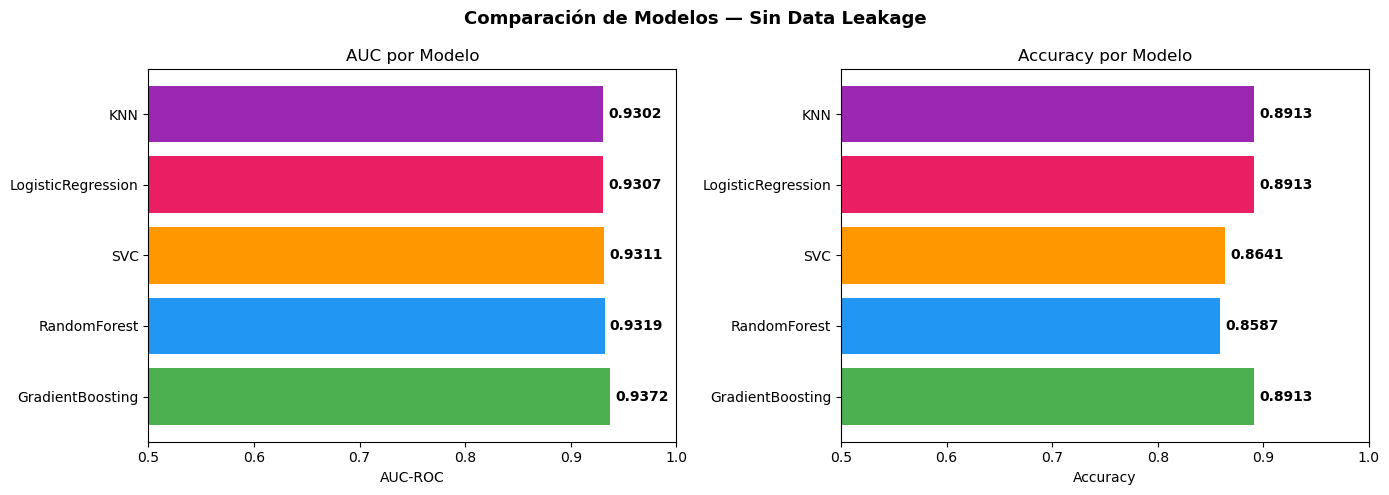

Gráfico guardado: model_comparison.png ✓


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparación de Modelos — Sin Data Leakage', fontsize=13, fontweight='bold')

colors = ['#4CAF50', '#2196F3', '#FF9800', '#E91E63', '#9C27B0']
modelos = results_df['Modelo']

# AUC
bars = axes[0].barh(modelos, results_df['AUC'], color=colors)
axes[0].set_xlabel('AUC-ROC')
axes[0].set_title('AUC por Modelo')
axes[0].set_xlim(0.5, 1.0)
for bar, val in zip(bars, results_df['AUC']):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontweight='bold')

# Accuracy
bars2 = axes[1].barh(modelos, results_df['Accuracy'], color=colors)
axes[1].set_xlabel('Accuracy')
axes[1].set_title('Accuracy por Modelo')
axes[1].set_xlim(0.5, 1.0)
for bar, val in zip(bars2, results_df['Accuracy']):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: model_comparison.png ✓')